## Test Statistic

The test statistic is a numerical value computed from the sample data that is used to assess the evidence against the null hypothesis. It summarizes the discrepancy between the observed data and what is expected under the null hypothesis.

The choice of the test statistic depends on the nature of the hypothesis being tested and the characteristics of the population distribution. Commonly used test statistics include z-scores, t-scores, F-statistics, and chi-square statistics.

## Z-Score

In statistics, a z-score (or standard score) is a measure that indicates how many standard deviations an observation or data point is away from the mean of a distribution. It helps standardize data by transforming it into a common scale.

The z-score of an observation $x$ in a distribution with mean $\mu$ and standard deviation $\sigma$ is calculated using the formula:

$$
z = \frac{x - \mu}{\sigma}
$$

A positive z-score indicates that the observation is above the mean, while a negative z-score indicates it is below the mean. A z-score of 0 means the observation is at the mean.

The standard normal distribution, also known as the z-distribution, is a special case where the mean is 0 and the standard deviation is 1. The z-score in this case is calculated using the formula:

$$
z = \frac{x - \mu}{\sigma} = \frac{x - 0}{1} = x
$$

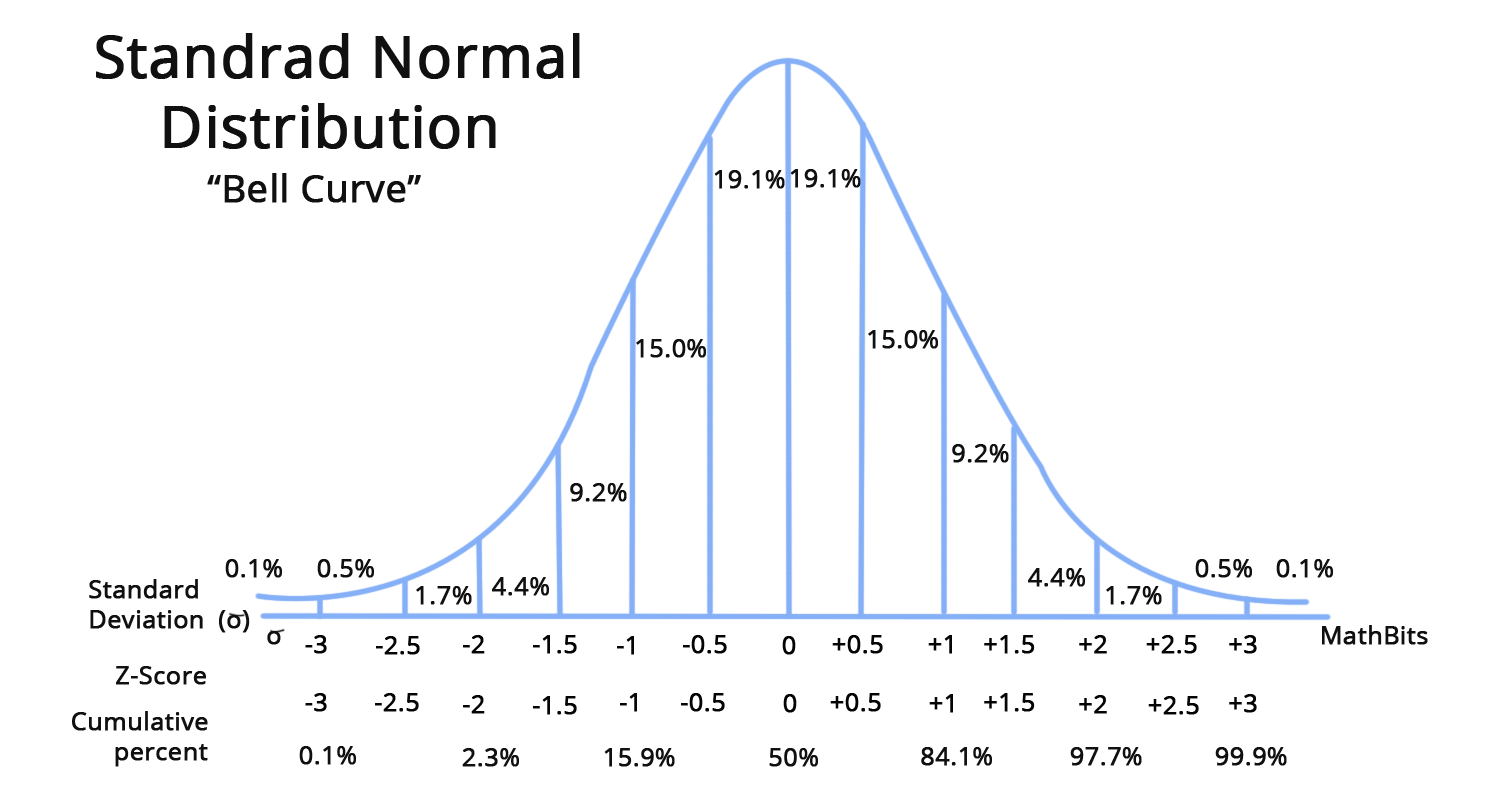

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd
df = pd.read_csv("../data/clean_titanic_dataset.csv")
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,initials
0,0.0,3.0,"Braund, Mr. Owen Harris",male,22.0,1.0,0.0,A/5 21171,7.2500,0,S,Mr
1,1.0,1.0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1.0,0.0,PC 17599,71.2833,1,C,Mrs
2,1.0,3.0,"Heikkinen, Miss. Laina",female,26.0,0.0,0.0,STON/O2. 3101282,7.9250,0,S,Miss
3,1.0,1.0,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1.0,0.0,113803,53.1000,1,S,Mrs
4,0.0,3.0,"Allen, Mr. William Henry",male,35.0,0.0,0.0,373450,8.0500,0,S,Mr


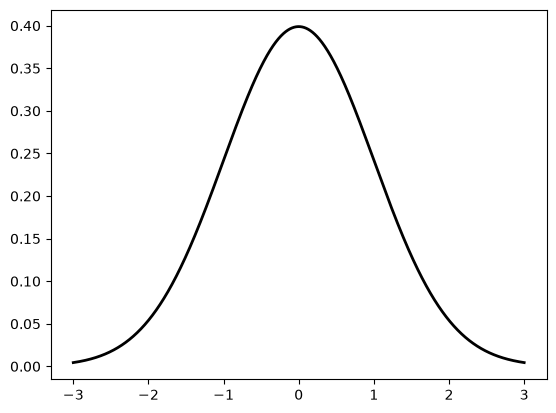

In [2]:
x = np.linspace(-3,3, 2000)
y = stats.norm.pdf(x)

plt.plot(
    x, 
    y, 
    "black", 
    lw = 2, 
    label = "Standard Normal Distribution"
)
plt.show()

# Calculatind and Interpreting Z-Score

In [3]:
sample = list(range(150, 200, 4))
sample

[150, 154, 158, 162, 166, 170, 174, 178, 182, 186, 190, 194, 198]

In [4]:
sample_mean = np.mean(sample)
sample_std = np.std(sample, ddof = 1)
print(sample_mean, sample_std)

174.0 15.57776192739723


In [5]:
z_score = (sample - sample_mean) / sample_std
z_score

array([-1.54065777, -1.28388148, -1.02710518, -0.77032889, -0.51355259,
       -0.2567763 ,  0.        ,  0.2567763 ,  0.51355259,  0.77032889,
        1.02710518,  1.28388148,  1.54065777])

In [6]:
for i , z in enumerate(z_score):
    print(f"Data point {i} : {sample[i]} has z-score = {z:.3f}")

Data point 0 : 150 has z-score = -1.541
Data point 1 : 154 has z-score = -1.284
Data point 2 : 158 has z-score = -1.027
Data point 3 : 162 has z-score = -0.770
Data point 4 : 166 has z-score = -0.514
Data point 5 : 170 has z-score = -0.257
Data point 6 : 174 has z-score = 0.000
Data point 7 : 178 has z-score = 0.257
Data point 8 : 182 has z-score = 0.514
Data point 9 : 186 has z-score = 0.770
Data point 10 : 190 has z-score = 1.027
Data point 11 : 194 has z-score = 1.284
Data point 12 : 198 has z-score = 1.541


In [7]:
Zscore = abs(df.Age - df.Age.mean()) / df.Age.std()
Zscore

0      0.554134
1      0.656215
2      0.251546
3      0.429275
4      0.429275
         ...   
884    0.175900
885    0.781074
886    0.629781
887    0.251546
888    0.202334
Name: Age, Length: 889, dtype: float64

In [8]:
df = df[Zscore <= 2.5]
df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,initials
0,0.0,3.0,"Braund, Mr. Owen Harris",male,22.0,1.0,0.0,A/5 21171,7.2500,0,S,Mr
1,1.0,1.0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1.0,0.0,PC 17599,71.2833,1,C,Mrs
2,1.0,3.0,"Heikkinen, Miss. Laina",female,26.0,0.0,0.0,STON/O2. 3101282,7.9250,0,S,Miss
3,1.0,1.0,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1.0,0.0,113803,53.1000,1,S,Mrs
4,0.0,3.0,"Allen, Mr. William Henry",male,35.0,0.0,0.0,373450,8.0500,0,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...
884,0.0,2.0,"Montvila, Rev. Juozas",male,27.0,0.0,0.0,211536,13.0000,0,S,Mr
885,1.0,1.0,"Graham, Miss. Margaret Edith",female,19.0,0.0,0.0,112053,30.0000,1,S,Miss
886,0.0,3.0,"Johnston, Miss. Catherine Helen ""Carrie""",female,21.0,1.0,2.0,W./C. 6607,23.4500,0,S,Miss
887,1.0,1.0,"Behr, Mr. Karl Howell",male,26.0,0.0,0.0,111369,30.0000,1,C,Mr
